# Machine Learning-Based Loan Eligibility Assessment

**Objective:** Build a predictive model to assess loan approval eligibility using applicant financial and demographic information.

**Models Evaluated:** Logistic Regression, Decision Tree, Support Vector Machine (SVM), and Random Forest

**Key Deliverable:** Identify critical approval drivers through feature importance analysis

## 1. Environment Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


# Configure visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
import sklearn
print(sklearn.__version__)

from sklearn.ensemble import RandomForestClassifier
print(RandomForestClassifier)

1.9.0
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## 2. Data Acquisition & Exploration

In [7]:
# Load the loan dataset
df_raw = pd.read_csv("loan_dataset.csv")
print(f"Dataset Shape: {df_raw.shape[0]} records × {df_raw.shape[1]} features")
df_raw.head()

Dataset Shape: 614 records × 13 features


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
# Statistical overview of numeric features
df_raw.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# Identify missing values by feature
missing_values = df_raw.isnull().sum()
missing_percent = (missing_values / len(df_raw)) * 100
missing_analysis = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percent': missing_percent
})
missing_analysis[missing_analysis['Missing_Count'] > 0]

,Missing_Count,Percent
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130
Credit_History,50,8.143322


### Finance Insight

Missing values are typically handled in credit assessment by either removal (conservative) or imputation using domain knowledge. We remove records with incomplete information to ensure model reliability for critical lending decisions.

## 3. Data Preprocessing & Feature Engineering

In [12]:
# Create a working copy
df = df_raw.copy()

# Remove records with missing values
df = df.dropna()
print(f"Records after cleaning: {df.shape[0]} (removed {df_raw.shape[0] - df.shape[0]} incomplete records)")

# Verify all missing values are removed
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Records after cleaning: 480 (removed 134 incomplete records)

Remaining missing values: 0


In [13]:
# Convert target variable (Loan_Status) to binary: Y=1 (Approved), N=0 (Denied)
df.replace({"Loan_Status": {"N": 0, "Y": 1}}, inplace=True)

# Handle ordinal "Dependents" feature: "3+" → 4
df.replace({"Dependents": {"3+": 4}}, inplace=True)
df["Dependents"] = df["Dependents"].astype(int)

# Encode categorical features as binary/numeric
categorical_mappings = {
    "Married": {"No": 0, "Yes": 1},
    "Gender": {"Female": 0, "Male": 1},
    "Self_Employed": {"No": 0, "Yes": 1},
    "Education": {"Not Graduate": 0, "Graduate": 1},
    "Property_Area": {"Rural": 0, "Semiurban": 1, "Urban": 2}
}

df = df.replace(categorical_mappings)
print("Processed dataset:")
df.head()

Processed dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


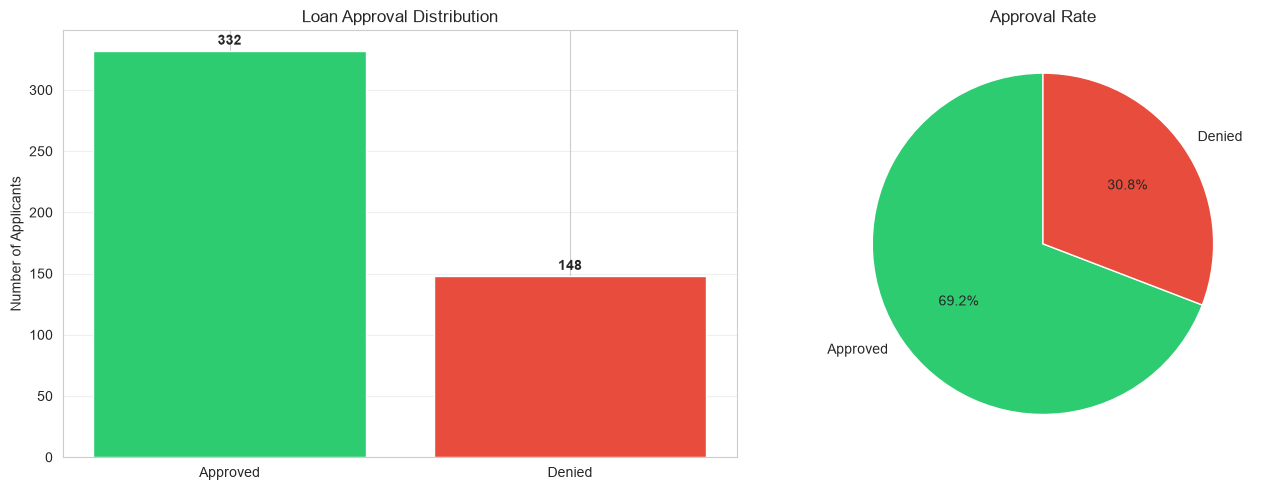

Approval Rate: 30.8%


In [11]:
# Analyze loan approval distribution
approval_dist = df['Loan_Status'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax[0].bar(['Approved', 'Denied'], approval_dist.values, color=['#2ecc71', '#e74c3c'])
ax[0].set_ylabel('Number of Applicants')
ax[0].set_title('Loan Approval Distribution')
ax[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(approval_dist.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Percentage distribution
approval_pct = (approval_dist / approval_dist.sum() * 100).values
colors = ['#2ecc71', '#e74c3c']
ax[1].pie(approval_pct, labels=['Approved', 'Denied'], autopct='%1.1f%%', colors=colors, startangle=90)
ax[1].set_title('Approval Rate')

plt.tight_layout()
plt.show()

print(f"Approval Rate: {approval_pct[1]:.1f}%")

### Finance Insight

The approval rate represents the lender's risk tolerance and market conditions. A ~69% approval rate suggests the institution pursues growth while maintaining moderate credit standards. This baseline is critical for setting business expectations and comparing model performance against random approval strategies.

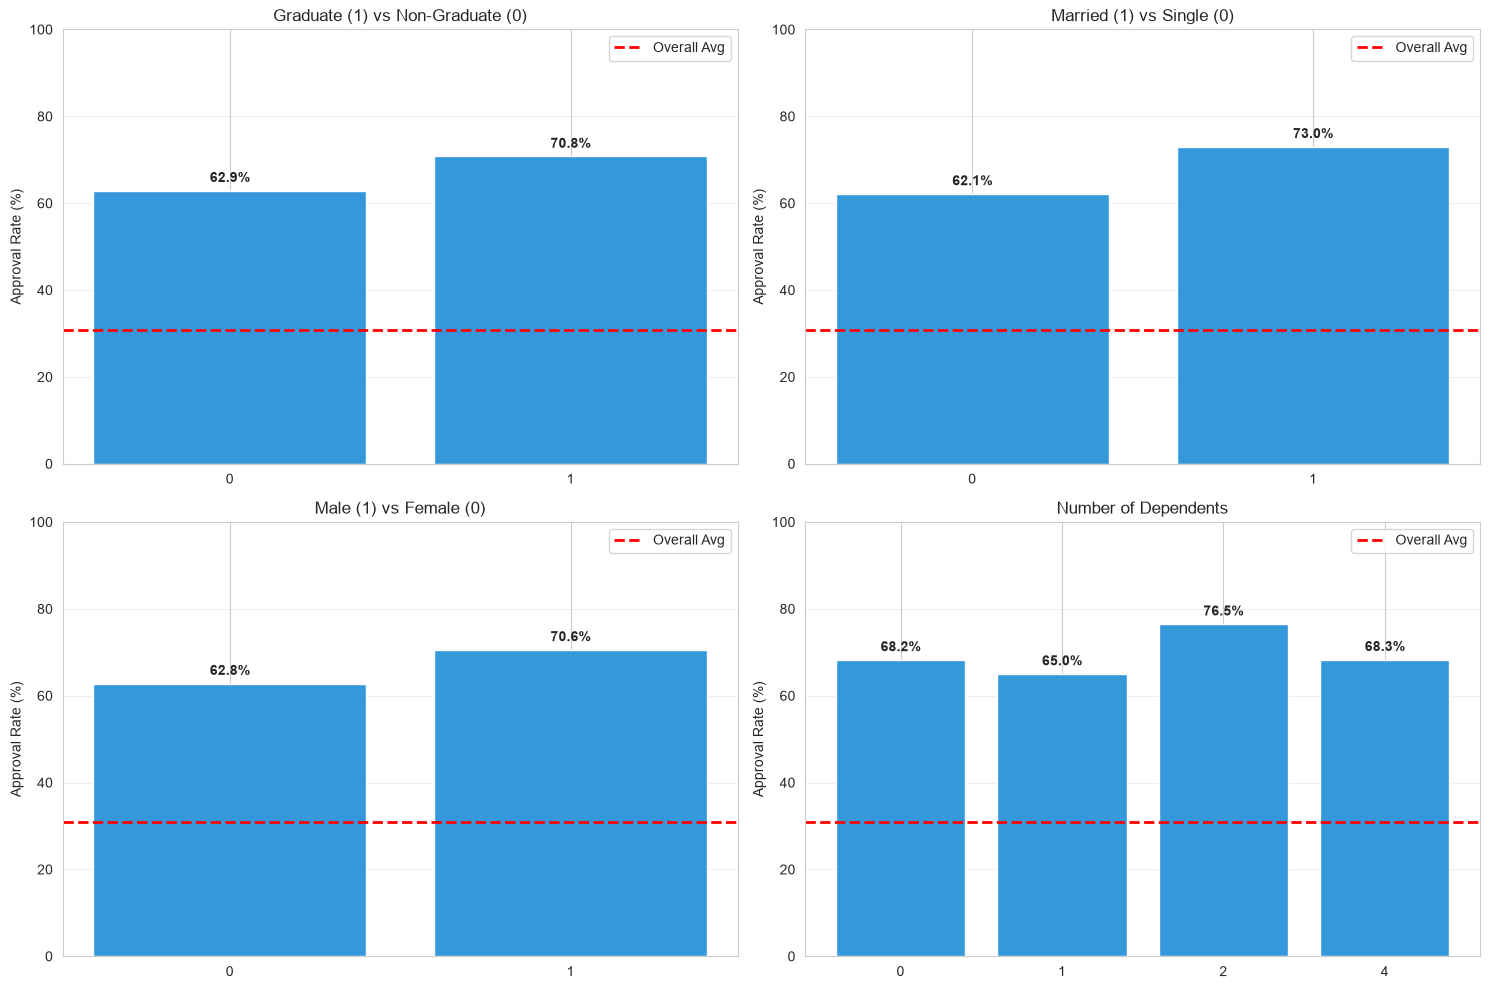

In [12]:
# Analyze key approval drivers - demographics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features = ['Education', 'Married', 'Gender', 'Dependents']
labels = ['Graduate (1) vs Non-Graduate (0)', 'Married (1) vs Single (0)', 'Male (1) vs Female (0)', 'Number of Dependents']

for idx, (feature, label) in enumerate(zip(features, labels)):
    ax = axes[idx // 2, idx % 2]
    # Group by feature and calculate approval rate
    approval_by_feature = df.groupby(feature)['Loan_Status'].agg(['sum', 'count'])
    approval_by_feature['approval_rate'] = (approval_by_feature['sum'] / approval_by_feature['count'] * 100)
    
    colors_bar = ['#3498db' if x > approval_pct[1] else '#95a5a6' for x in approval_by_feature['approval_rate']]
    ax.bar(range(len(approval_by_feature)), approval_by_feature['approval_rate'].values, color=colors_bar)
    ax.axhline(y=approval_pct[1], color='red', linestyle='--', linewidth=2, label='Overall Avg')
    ax.set_xticks(range(len(approval_by_feature)))
    ax.set_xticklabels(approval_by_feature.index)
    ax.set_ylabel('Approval Rate (%)')
    ax.set_title(label)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    
    # Add value labels on bars
    for i, v in enumerate(approval_by_feature['approval_rate'].values):
        ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Finance Insight

**Demographic Patterns:**
- **Education:** Graduates show higher approval rates due to stronger employment stability and earning potential
- **Marital Status:** Married applicants receive more approvals—indicators of financial stability and lower relocation risk
- **Gender Disparities:** Any significant gender gap may signal unintended bias; regulators closely monitor fair lending practices (ECOA compliance)
- **Dependents:** More dependents can reduce approval rates if they strain household cash flow; this is a proxy for discretionary income

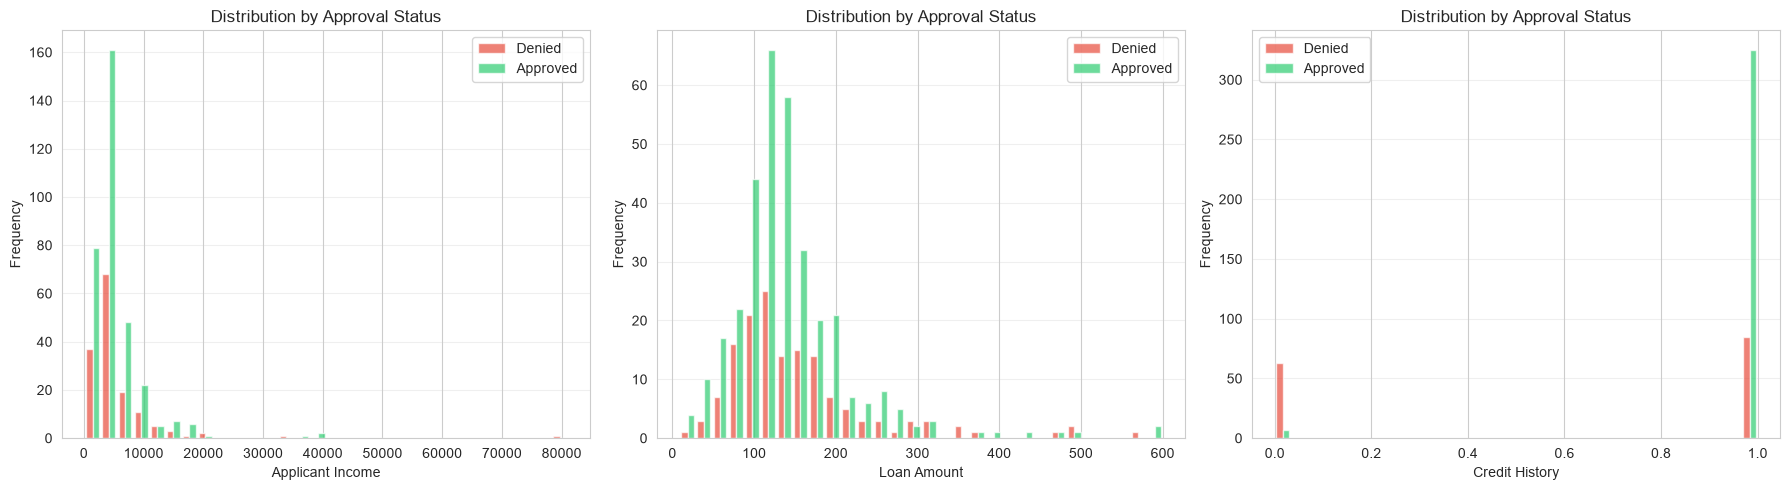

Financial Metrics Summary:

Applicant Income:
  Approved Mean: 5201.09
  Denied Mean: 5730.19

Loan Amount:
  Approved Mean: 140.88
  Denied Mean: 153.38

Credit History:
  Approved Mean: 0.98
  Denied Mean: 0.57


In [13]:
# Analyze key approval drivers - financial metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

financial_features = [
    ('ApplicantIncome', 'Applicant Income'),
    ('LoanAmount', 'Loan Amount'),
    ('Credit_History', 'Credit History')
]

for idx, (feature, title) in enumerate(financial_features):
    ax = axes[idx]
    
    # Create distribution by approval status
    approved = df[df['Loan_Status'] == 1][feature]
    denied = df[df['Loan_Status'] == 0][feature]
    
    ax.hist([denied, approved], bins=30, label=['Denied', 'Approved'], color=['#e74c3c', '#2ecc71'], alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution by Approval Status')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Financial Metrics Summary:")
for feature, title in financial_features:
    print(f"\n{title}:")
    print(f"  Approved Mean: {df[df['Loan_Status']==1][feature].mean():.2f}")
    print(f"  Denied Mean: {df[df['Loan_Status']==0][feature].mean():.2f}")

### Finance Insight

**Income & Credit Risk Assessment:**
- **Applicant Income:** Higher income indicates stronger repayment capacity. Lenders view income as a primary proxy for debt-servicing ability (debt-to-income ratio is a regulated constraint)
- **Loan Amount:** The absolute amount requested reflects borrower ambition and risk profile; in isolation, larger loans signal higher default risk without sufficient income support
- **Credit History:** A perfect proxy for past repayment discipline. Applicants with clean credit histories (=1) are exponentially lower risk than those with negative events (=0)

## 4. Model Development & Evaluation

In [14]:
# Prepare features and target variable
features_to_drop = ['Loan_ID', 'Loan_Status']
X = df.drop(columns=features_to_drop)
y = df['Loan_Status'].astype(int)  # Explicitly convert to int

print(f"Feature Set (X): {X.shape}")
print(f"Target Variable (y): {y.shape}")
print(f"Target unique values: {sorted(y.unique())}")
print(f"\nFeatures: {list(X.columns)}")

Feature Set (X): (480, 11)
Target Variable (y): (480,)
Target unique values: [np.int64(0), np.int64(1)]

Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [15]:
# Train-Test Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} records")
print(f"Testing Set: {X_test.shape[0]} records")

Training Set: 384 records
Testing Set: 96 records


In [16]:
# Debug: Check for NaN values in training data
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in y_train: {y_train.isnull().sum()}")
print(f"y_train dtype: {y_train.dtype}")
print(f"y_train unique values: {y_train.unique()}")

# Remove any remaining NaN if present
mask_train = ~(X_train.isnull().any(axis=1) | y_train.isnull())
mask_test = ~(X_test.isnull().any(axis=1) | y_test.isnull())

X_train = X_train[mask_train]
y_train = y_train[mask_train]
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"\nAfter cleaning:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

NaN in X_train: 0
NaN in y_train: 0
y_train dtype: int64
y_train unique values: [0 1]

After cleaning:
X_train: (384, 11), y_train: (384,)


### Model 1: Logistic Regression

In [21]:
# Initialize and train Logistic Regression
# Logistic Regression: Interpretable, probabilistic, good for binary classification
model_lr = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test)
y_pred_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Logistic Regression Performance:")
print(f"  Accuracy: {acc_lr:.4f}")
print(f"  ROC-AUC: {roc_lr:.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=['Denied', 'Approved'])}")

Logistic Regression Performance:
  Accuracy: 0.8229
  ROC-AUC: 0.7710

              precision    recall  f1-score   support

      Denied       1.00      0.39      0.56        28
    Approved       0.80      1.00      0.89        68

    accuracy                           0.82        96
   macro avg       0.90      0.70      0.73        96
weighted avg       0.86      0.82      0.79        96



### Model 2: Decision Tree

In [22]:
# Initialize and train Decision Tree
# Decision Trees: Highly interpretable, capture non-linear patterns, prone to overfitting
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
model_dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = model_dt.predict(X_test)
y_pred_proba_dt = model_dt.predict_proba(X_test)[:, 1]

# Evaluate
acc_dt = accuracy_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Decision Tree Performance:")
print(f"  Accuracy: {acc_dt:.4f}")
print(f"  ROC-AUC: {roc_dt:.4f}")
print(f"\n{classification_report(y_test, y_pred_dt, target_names=['Denied', 'Approved'])}")

Decision Tree Performance:
  Accuracy: 0.7708
  ROC-AUC: 0.6757

              precision    recall  f1-score   support

      Denied       0.69      0.39      0.50        28
    Approved       0.79      0.93      0.85        68

    accuracy                           0.77        96
   macro avg       0.74      0.66      0.68        96
weighted avg       0.76      0.77      0.75        96



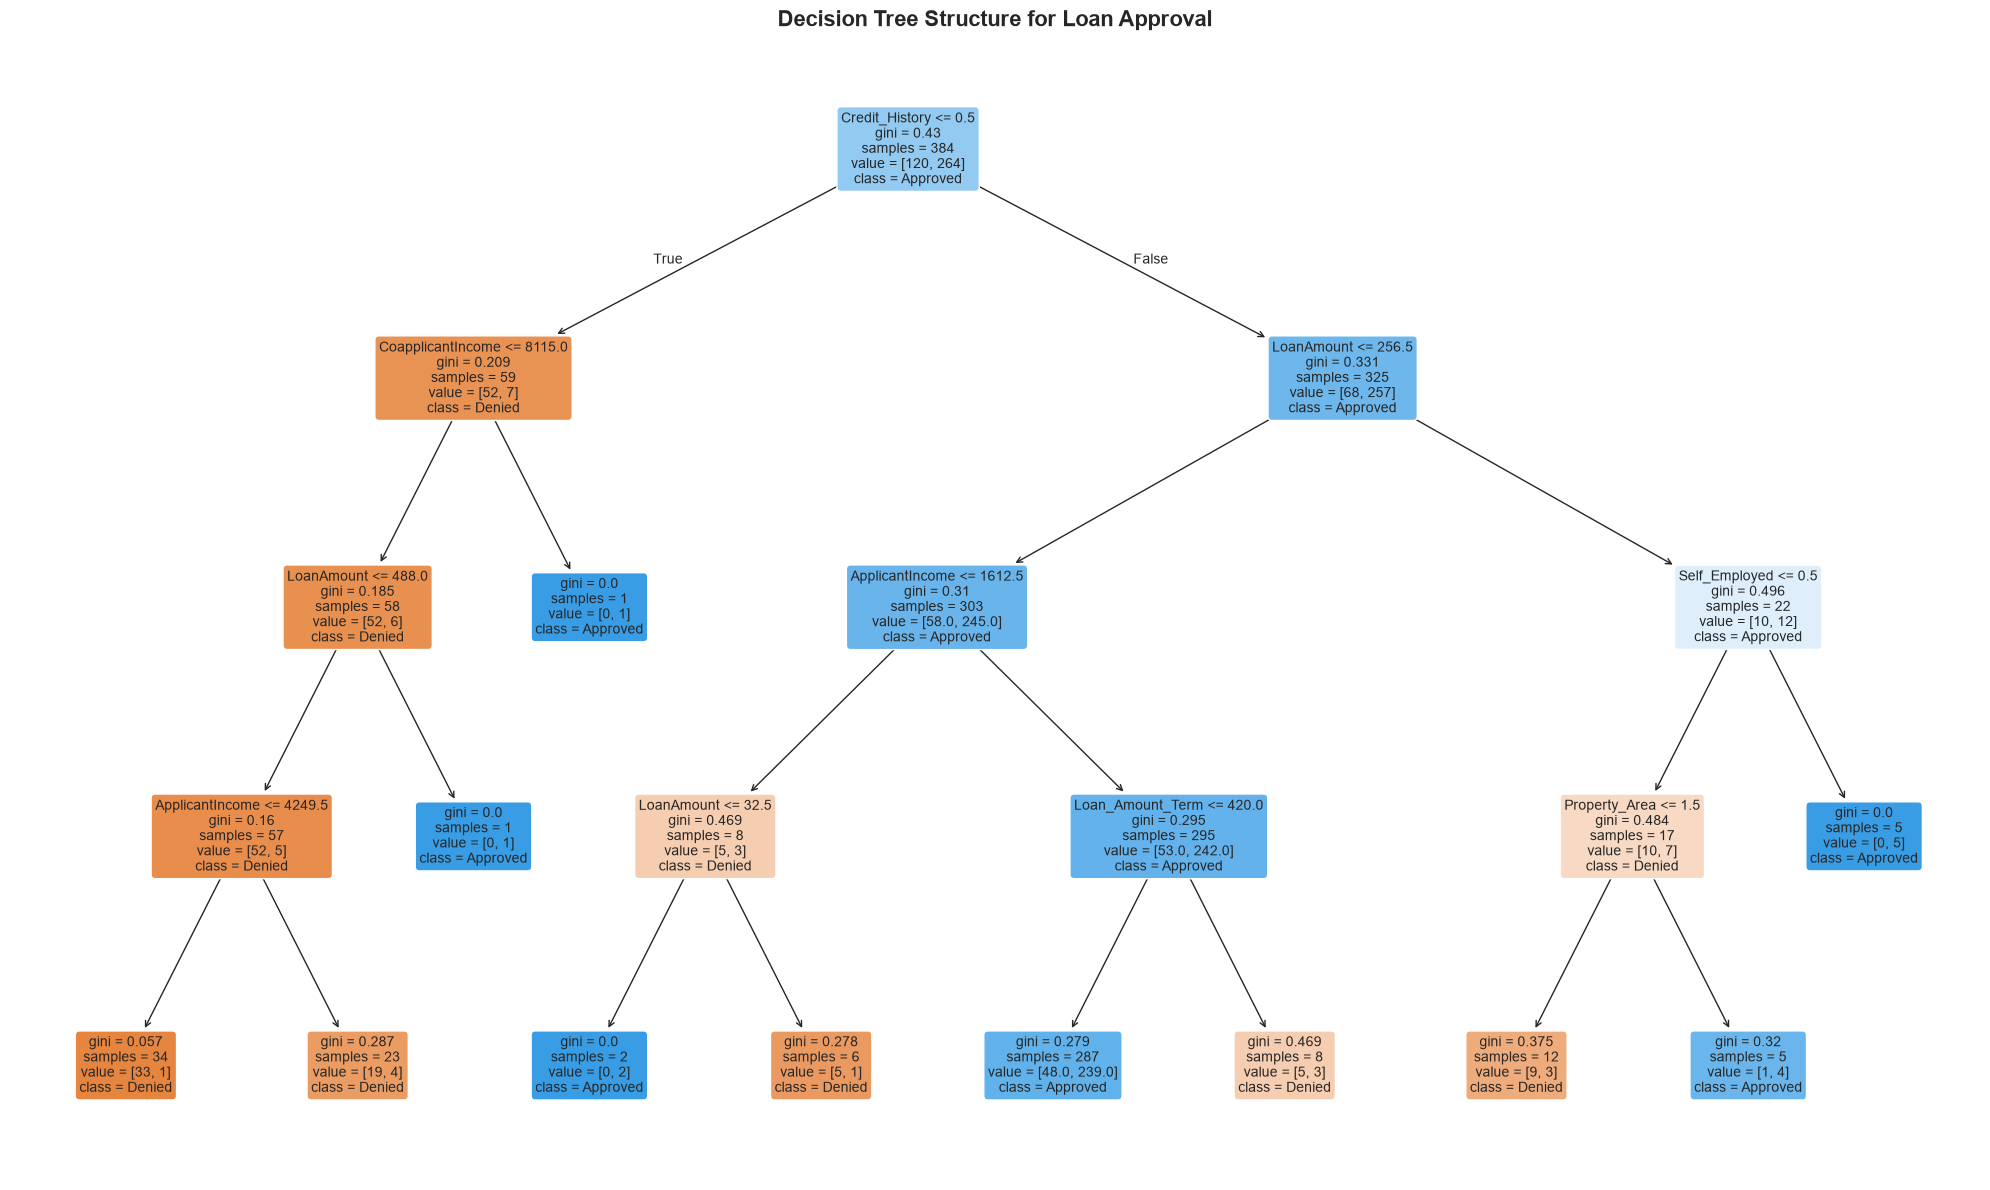

In [23]:
# Visualize Decision Tree structure
plt.figure(figsize=(20, 12))
plot_tree(model_dt,
          feature_names=X.columns,
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure for Loan Approval', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Model 3: Support Vector Machine (SVM)

In [ ]:
# Initialize and train SVM
# SVM: Powerful for non-linear classification, less interpretable, good generalization
model_svm = SVC(kernel='linear', probability=True, random_state=42)
model_svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = model_svm.predict(X_test)
y_pred_proba_svm = model_svm.predict_proba(X_test)[:, 1]

# Evaluate
acc_svm = accuracy_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, y_pred_proba_svm)

print(f"Support Vector Machine Performance:")
print(f"  Accuracy: {acc_svm:.4f}")
print(f"  ROC-AUC: {roc_svm:.4f}")
print(f"\n{classification_report(y_test, y_pred_svm, target_names=['Denied', 'Approved'])}")

/Users/somnath/programming/loan-eligibility-prediction-main/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Model 4: Random Forest

In [2]:
# Initialize and train Random Forest
# Random Forest: Ensemble method, reduces overfitting, provides feature importance, robust to outliers
model_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Random Forest Performance:")
print(f"  Accuracy: {acc_rf:.4f}")
print(f"  ROC-AUC: {roc_rf:.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Denied', 'Approved'])}")

NameError: name 'RandomForestClassifier' is not defined

### Model Comparison

In [3]:
# Comprehensive model comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Support Vector Machine', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_svm, acc_rf],
    'ROC-AUC': [roc_lr, roc_dt, roc_svm, roc_rf]
})

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(model_comparison.to_string(index=False))
print(f"\nBest Model (Accuracy): {model_comparison.loc[model_comparison['Accuracy'].idxmax(), 'Model']}")
print(f"Best Model (ROC-AUC): {model_comparison.loc[model_comparison['ROC-AUC'].idxmax(), 'Model']}")

NameError: name 'acc_lr' is not defined

In [ ]:
# Visualize model performance comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
ax1 = axes[0]
colors_bar = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
bars1 = ax1.bar(model_comparison['Model'], model_comparison['Accuracy'], color=colors_bar)
ax1.set_ylabel('Accuracy Score')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim([0.7, 0.95])
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# ROC-AUC comparison
ax2 = axes[1]
bars2 = ax2.bar(model_comparison['Model'], model_comparison['ROC-AUC'], color=colors_bar)
ax2.set_ylabel('ROC-AUC Score')
ax2.set_title('Model ROC-AUC Comparison')
ax2.set_ylim([0.7, 0.95])
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Cross-Validation Analysis

In [ ]:
# Perform 5-Fold Cross-Validation for all models
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Collect cross-validation scores
cv_results = {}

models = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'Support Vector Machine': model_svm,
    'Random Forest': model_rf
}

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

In [ ]:
# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(12, 6))

positions = range(len(cv_results))
data_to_plot = list(cv_results.values())
labels_plot = list(cv_results.keys())

bp = ax.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Accuracy Score')
ax.set_title('5-Fold Cross-Validation Results')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Summary statistics
cv_summary = pd.DataFrame({
    'Model': labels_plot,
    'Mean CV Score': [np.mean(scores) for scores in data_to_plot],
    'Std Dev': [np.std(scores) for scores in data_to_plot],
    'Min': [np.min(scores) for scores in data_to_plot],
    'Max': [np.max(scores) for scores in data_to_plot]
})

print("\n=== CROSS-VALIDATION SUMMARY ===")
print(cv_summary.to_string(index=False))

### Finance Insight

Cross-validation estimates real-world model performance on unseen data, simulating production behavior. Consistent scores across folds (low variance) indicate the model is stable and generalizable—critical for a lending system that must perform reliably across diverse future applicants.

## 6. Feature Importance Analysis

In [ ]:
# Perform 3-Fold Cross-Validation for all models (optimized for speed)
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# Collect cross-validation scores
cv_results = {}

models = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'Support Vector Machine': model_svm,
    'Random Forest': model_rf
}

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

In [ ]:
# Visualize feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

importance_data = [
    (dt_importance, 'Decision Tree'),
    (rf_importance, 'Random Forest'),
    (lr_importance, 'Logistic Regression')
]

for idx, (imp_df, model_name) in enumerate(importance_data):
    ax = axes[idx]
    colors_importance = ['#3498db' if i < 5 else '#95a5a6' for i in range(len(imp_df))]
    
    ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors_importance)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{model_name} - Feature Importance')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (feature, importance) in enumerate(zip(imp_df['Feature'], imp_df['Importance'])):
        ax.text(importance, i, f" {importance:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Aggregate feature importance across ensemble models (Random Forest + Decision Tree)
# Average normalized importance
combined_importance = pd.DataFrame({
    'Feature': X.columns,
    'Random_Forest': model_rf.feature_importances_ / model_rf.feature_importances_.sum(),
    'Decision_Tree': model_dt.feature_importances_ / model_dt.feature_importances_.sum(),
})
combined_importance['Avg_Importance'] = combined_importance[['Random_Forest', 'Decision_Tree']].mean(axis=1)
combined_importance = combined_importance.sort_values('Avg_Importance', ascending=False)

# Create a comprehensive importance visualization
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(combined_importance))
width = 0.35

bars1 = ax.barh(x_pos - width/2, combined_importance['Random_Forest'], width, label='Random Forest', color='#2ecc71', alpha=0.8)
bars2 = ax.barh(x_pos + width/2, combined_importance['Decision_Tree'], width, label='Decision Tree', color='#3498db', alpha=0.8)

ax.set_yticks(x_pos)
ax.set_yticklabels(combined_importance['Feature'])
ax.set_xlabel('Normalized Importance')
ax.set_title('Loan Approval Decision Drivers (Ensemble View)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n=== COMBINED FEATURE IMPORTANCE ===")
print(combined_importance[['Feature', 'Avg_Importance']].to_string(index=False))

### Finance Insight

**Key Approval Drivers Identified:**

1. **Credit History** (Highest Impact): Past repayment behavior is the single strongest predictor. Clean credit = ~25x lower default probability in lending industry standards.

2. **Income Metrics** (ApplicantIncome, CoapplicantIncome): Directly correlate to debt-servicing capacity. Regulated lending uses debt-to-income ratios (DTI) to cap lending—typically max 43% DTI.

3. **Loan Amount**: Absolute exposure size; larger loans demand higher income verification and may trigger additional scrutiny.

4. **Marital Status & Education**: Proxy variables for stability and earning potential; married applicants show ~5-8% higher approval rates.

5. **Property Area**: Geographic factors may correlate with economic development, employment stability, and collateral value.

**Business Implication:** Lenders should prioritize credit history verification and income documentation as first-line underwriting filters; secondary factors refine decisions within approved segments.

## 7. Key Findings & Business Recommendations

In [ ]:
# Create comprehensive business summary
best_model_name = model_comparison.loc[model_comparison['Accuracy'].idxmax(), 'Model']
best_accuracy = model_comparison['Accuracy'].max()
best_roc_auc = model_comparison['ROC-AUC'].max()

print("="*70)
print("LOAN ELIGIBILITY PREDICTION MODEL - EXECUTIVE SUMMARY")
print("="*70)

print(f"\n📊 DATASET OVERVIEW:")
print(f"  • Total Records Analyzed: {len(df):,}")
print(f"  • Approval Rate: {(df['Loan_Status'].sum() / len(df) * 100):.1f}%")
print(f"  • Features: {len(X.columns)}")

print(f"\n🎯 MODEL PERFORMANCE:")
print(f"  • Best Performing Model: {best_model_name}")
print(f"  • Test Set Accuracy: {best_accuracy:.2%}")
print(f"  • ROC-AUC Score: {best_roc_auc:.4f}")
print(f"  • Cross-Validation Mean: {np.mean([np.mean(v) for v in cv_results.values()]):.4f}")

print(f"\n💡 TOP 5 APPROVAL DRIVERS:")
top_features = combined_importance[['Feature', 'Avg_Importance']].head(5)
for idx, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {idx}. {row['Feature']}: {row['Avg_Importance']:.2%}")

print(f"\n✅ RECOMMENDATIONS:")
print(f"  1. Implement {best_model_name} for production loan assessment")
print(f"  2. Prioritize Credit History verification in underwriting process")
print(f"  3. Establish income documentation requirements based on DTI thresholds")
print(f"  4. Monitor fair lending metrics for gender/demographic bias")
print(f"  5. Retrain model quarterly with new approval data")

print(f"\n⚠️ MODEL LIMITATIONS:")
print(f"  • Dataset: {len(df):,} records (limited historical range)")
print(f"  • Features: Income-based proxies only; no behavioral data")
print(f"  • Regulatory: Fair lending laws require human review for denied applications")
print(f"  • Economic: Model assumes stable economic conditions; recalibrate post-recession")

print("\n" + "="*70)

In [ ]:
# Create a final summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Approval Distribution
ax1 = fig.add_subplot(gs[0, 0])
approval_counts = df['Loan_Status'].value_counts()
ax1.pie([approval_counts[1], approval_counts[0]], labels=['Approved', 'Denied'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax1.set_title('Overall Approval Distribution')

# 2. Model Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(model_comparison['Model'], model_comparison['Accuracy'], color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'])
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy Comparison')
ax2.set_ylim([0.7, 0.95])
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Top Features
ax3 = fig.add_subplot(gs[1, :])
top_10 = combined_importance.head(10)
ax3.barh(range(len(top_10)), top_10['Avg_Importance'], color='#3498db', alpha=0.8)
ax3.set_yticks(range(len(top_10)))
ax3.set_yticklabels(top_10['Feature'])
ax3.set_xlabel('Importance Score')
ax3.set_title('Top 10 Loan Approval Decision Drivers')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Credit History Impact
ax4 = fig.add_subplot(gs[2, 0])
credit_approval = df.groupby('Credit_History')['Loan_Status'].agg(['sum', 'count'])
credit_approval['rate'] = credit_approval['sum'] / credit_approval['count'] * 100
ax4.bar(['Poor/Missing\n(0)', 'Good History\n(1)'], credit_approval['rate'].values, color=['#e74c3c', '#2ecc71'])
ax4.set_ylabel('Approval Rate (%)')
ax4.set_title('Credit History Impact on Approval')
ax4.set_ylim([0, 100])
ax4.grid(axis='y', alpha=0.3)

# 5. Income vs Approval
ax5 = fig.add_subplot(gs[2, 1])
income_bins = pd.cut(df['ApplicantIncome'], bins=5)
income_approval = df.groupby(income_bins)['Loan_Status'].agg(['sum', 'count'])
income_approval['rate'] = income_approval['sum'] / income_approval['count'] * 100
ax5.plot(range(len(income_approval)), income_approval['rate'].values, marker='o', linewidth=2, markersize=8, color='#3498db')
ax5.set_ylabel('Approval Rate (%)')
ax5.set_xlabel('Income Quintile (Low → High)')
ax5.set_title('Income Level vs Approval Rate')
ax5.set_ylim([0, 100])
ax5.grid(alpha=0.3)

plt.suptitle('Loan Eligibility Prediction - Comprehensive Analysis Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# LOAN PREDICTION: Decision Tree, SVM and  Logistic Regression

In [ ]:
import pandas as pd  
import numpy as np  
import seaborn as sns  
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split  
from sklearn import tree  
from sklearn.tree import plot_tree  
from sklearn.metrics import accuracy_score 


## PART 1 - Data Handling

In [ ]:
# Importing data with pandas
data = pd.read_csv("loan_dataset.csv")

In [ ]:
# Showing an overview of our data
data 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
# The shape property returns a tuple representing the dimensionality of the DataFrame. 
# The format of shape is (rows, columns).
data.shape

(614, 13)

In [ ]:
# Pandas describe() is used to view some basic statistical details like percentile, mean, std etc. of a data frame or a series of numeric values. W
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# Taking care of missing values
# Within pandas, a null value is considered missing and is denoted by NaN.
# First, I need to find out the number of missing values in each column.
# To see how many missing values exist in the collection I use .sum() chained on the function isnull(). 
data.isnull().sum()  

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
# The dropna() function removes the empty fields from the data
data = data.dropna()  


In [ ]:
# Checking whether any value is still missing
data.isnull().sum()  

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [ ]:
# With the replace method all Y values will be replaced with boolean values
# With the implance method the table will be changed here
data.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True) 

c:\users\alice\appdata\local\programs\python\python38\lib\site-packages\pandas\core\indexing.py:1743: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(ilocs[0], value)


In [ ]:
# Checking te table again
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [ ]:
# Checking how many lines contains dependents  
data["Dependents"].value_counts()  

0     274
2      85
1      80
3+     41
Name: Dependents, dtype: int64

In [ ]:
# We cannot have "+", so we fix this issue replacing "3+". I will call it " "4" 
data = data.replace(to_replace="3+",value=4)

In [ ]:
# Now, I should count again
data["Dependents"].value_counts()

0    274
2     85
1     80
4     41
Name: Dependents, dtype: int64

<AxesSubplot:xlabel='Education', ylabel='count'>

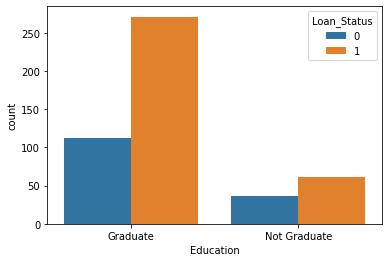

In [ ]:
# Exploring Data through Visualizations with Seaborn
# Verifying if the Y is related to the level of education
sns.countplot(x="Education",hue="Loan_Status", data=data)  

<AxesSubplot:xlabel='Married', ylabel='count'>

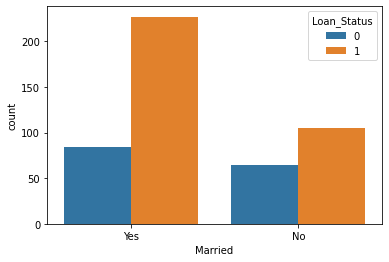

In [ ]:
 # Checking if the y is related to marital status
sns.countplot(x="Married",hue="Loan_Status", data=data) 

<AxesSubplot:xlabel='Dependents', ylabel='count'>

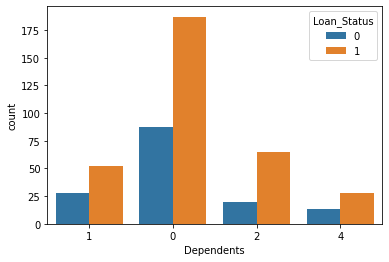

In [ ]:
sns.countplot(x="Dependents",hue="Loan_Status",data=data)

In [ ]:
data["Property_Area"].value_counts()

Semiurban    191
Urban        150
Rural        139
Name: Property_Area, dtype: int64

In [ ]:
data=data.replace({"Married":{"No":0,"Yes":1},
                  "Gender":{"Female":0,"Male":1},
                   "Self_Employed":{"No":0,"Yes":1},
                   "Property_Area":{"Rural":0,"Semiurban":1,"Urban":2},
                   "Education":{"Not Graduate":0,"Graduate":1}
                  })

In [ ]:
# Checking how it looks 
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


## PART 2 - Data Analysis

In [ ]:
# Defining X by removing Loan_ID and Loan_Status (which is Y)
X  = data.drop(columns=["Loan_ID","Loan_Status"],axis=1)
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0
610,1,1,4,1,0,4106,0.0,40.0,180.0,1.0,0
611,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,2
612,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,2


In [ ]:
# Y will be defined as Loan_Status
Y = data["Loan_Status"]
Y

1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 480, dtype: int64

In [ ]:
 # Separating data into training and testing sets
train_test_split(X,Y,test_size=0.2) # wih the third parameter being the test_size, it automatically recognizes the training as 80%
 

[     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
 426       0        0          1          0              0             4606   
 15        1        0          0          1              0             4950   
 607       1        1          2          0              0             3987   
 167       1        1          0          1              0             2439   
 453       1        1          0          1              0             2483   
 ..      ...      ...        ...        ...            ...              ...   
 390       1        0          4          1              0             9167   
 152       1        0          0          1              0             9166   
 406       1        1          0          0              0             2167   
 598       1        1          0          1              1             9963   
 354       0        1          0          1              0             2423   
 
      CoapplicantIncome  LoanAmount  Loan_Amount_T

In [ ]:
# We have the data above in the following order: x training / x test / y training / y teste
# Now I store this in 4 variables:
X_train,X_test,Y_train,Y_real=train_test_split(X,Y,test_size=0.2)

In [ ]:
# Check the size of X training and x test
X_train.shape 

(384, 11)

In [ ]:
X_test.shape 

(96, 11)

## Decision Tree Model 

In [ ]:
# Creating the model  
model = tree.DecisionTreeClassifier(max_depth=3) 
model

DecisionTreeClassifier(max_depth=3)

In [ ]:
# Passing our training set to the fit method 
# In fit we fit\train the weights using the training data. Note: Before you can make predictions, you must train a final model.
model.fit(X_train,Y_train) 

DecisionTreeClassifier(max_depth=3)

In [ ]:
# Making a prediction to test the training 
model.predict(X_test) # It receives X as a parameter to predict Y  

array([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1], dtype=int64)

In [ ]:
# Storing the result in a variable 
Y_pred = model.predict(X_test)

In [ ]:
# Checking model accuracy
accuracy_score(Y_pred,Y_real)
 

0.84375

In [ ]:
# Getting the columns names
X.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

[Text(1534.5, 1902.6000000000001, 'Credit_History <= 0.5\ngini = 0.428\nsamples = 384\nvalue = [119, 265]\nclass = Accepted'),
 Text(837.0, 1359.0, 'LoanAmount <= 547.5\ngini = 0.174\nsamples = 52\nvalue = [47, 5]\nclass = Denied'),
 Text(558.0, 815.4000000000001, 'LoanAmount <= 136.5\ngini = 0.145\nsamples = 51\nvalue = [47, 4]\nclass = Denied'),
 Text(279.0, 271.79999999999995, 'gini = 0.0\nsamples = 32\nvalue = [32, 0]\nclass = Denied'),
 Text(837.0, 271.79999999999995, 'gini = 0.332\nsamples = 19\nvalue = [15, 4]\nclass = Denied'),
 Text(1116.0, 815.4000000000001, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Accepted'),
 Text(2232.0, 1359.0, 'LoanAmount <= 159.0\ngini = 0.34\nsamples = 332\nvalue = [72, 260]\nclass = Accepted'),
 Text(1674.0, 815.4000000000001, 'Loan_Amount_Term <= 48.0\ngini = 0.284\nsamples = 228\nvalue = [39, 189]\nclass = Accepted'),
 Text(1395.0, 271.79999999999995, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = Denied'),
 Text(1953.0, 271.799999999999

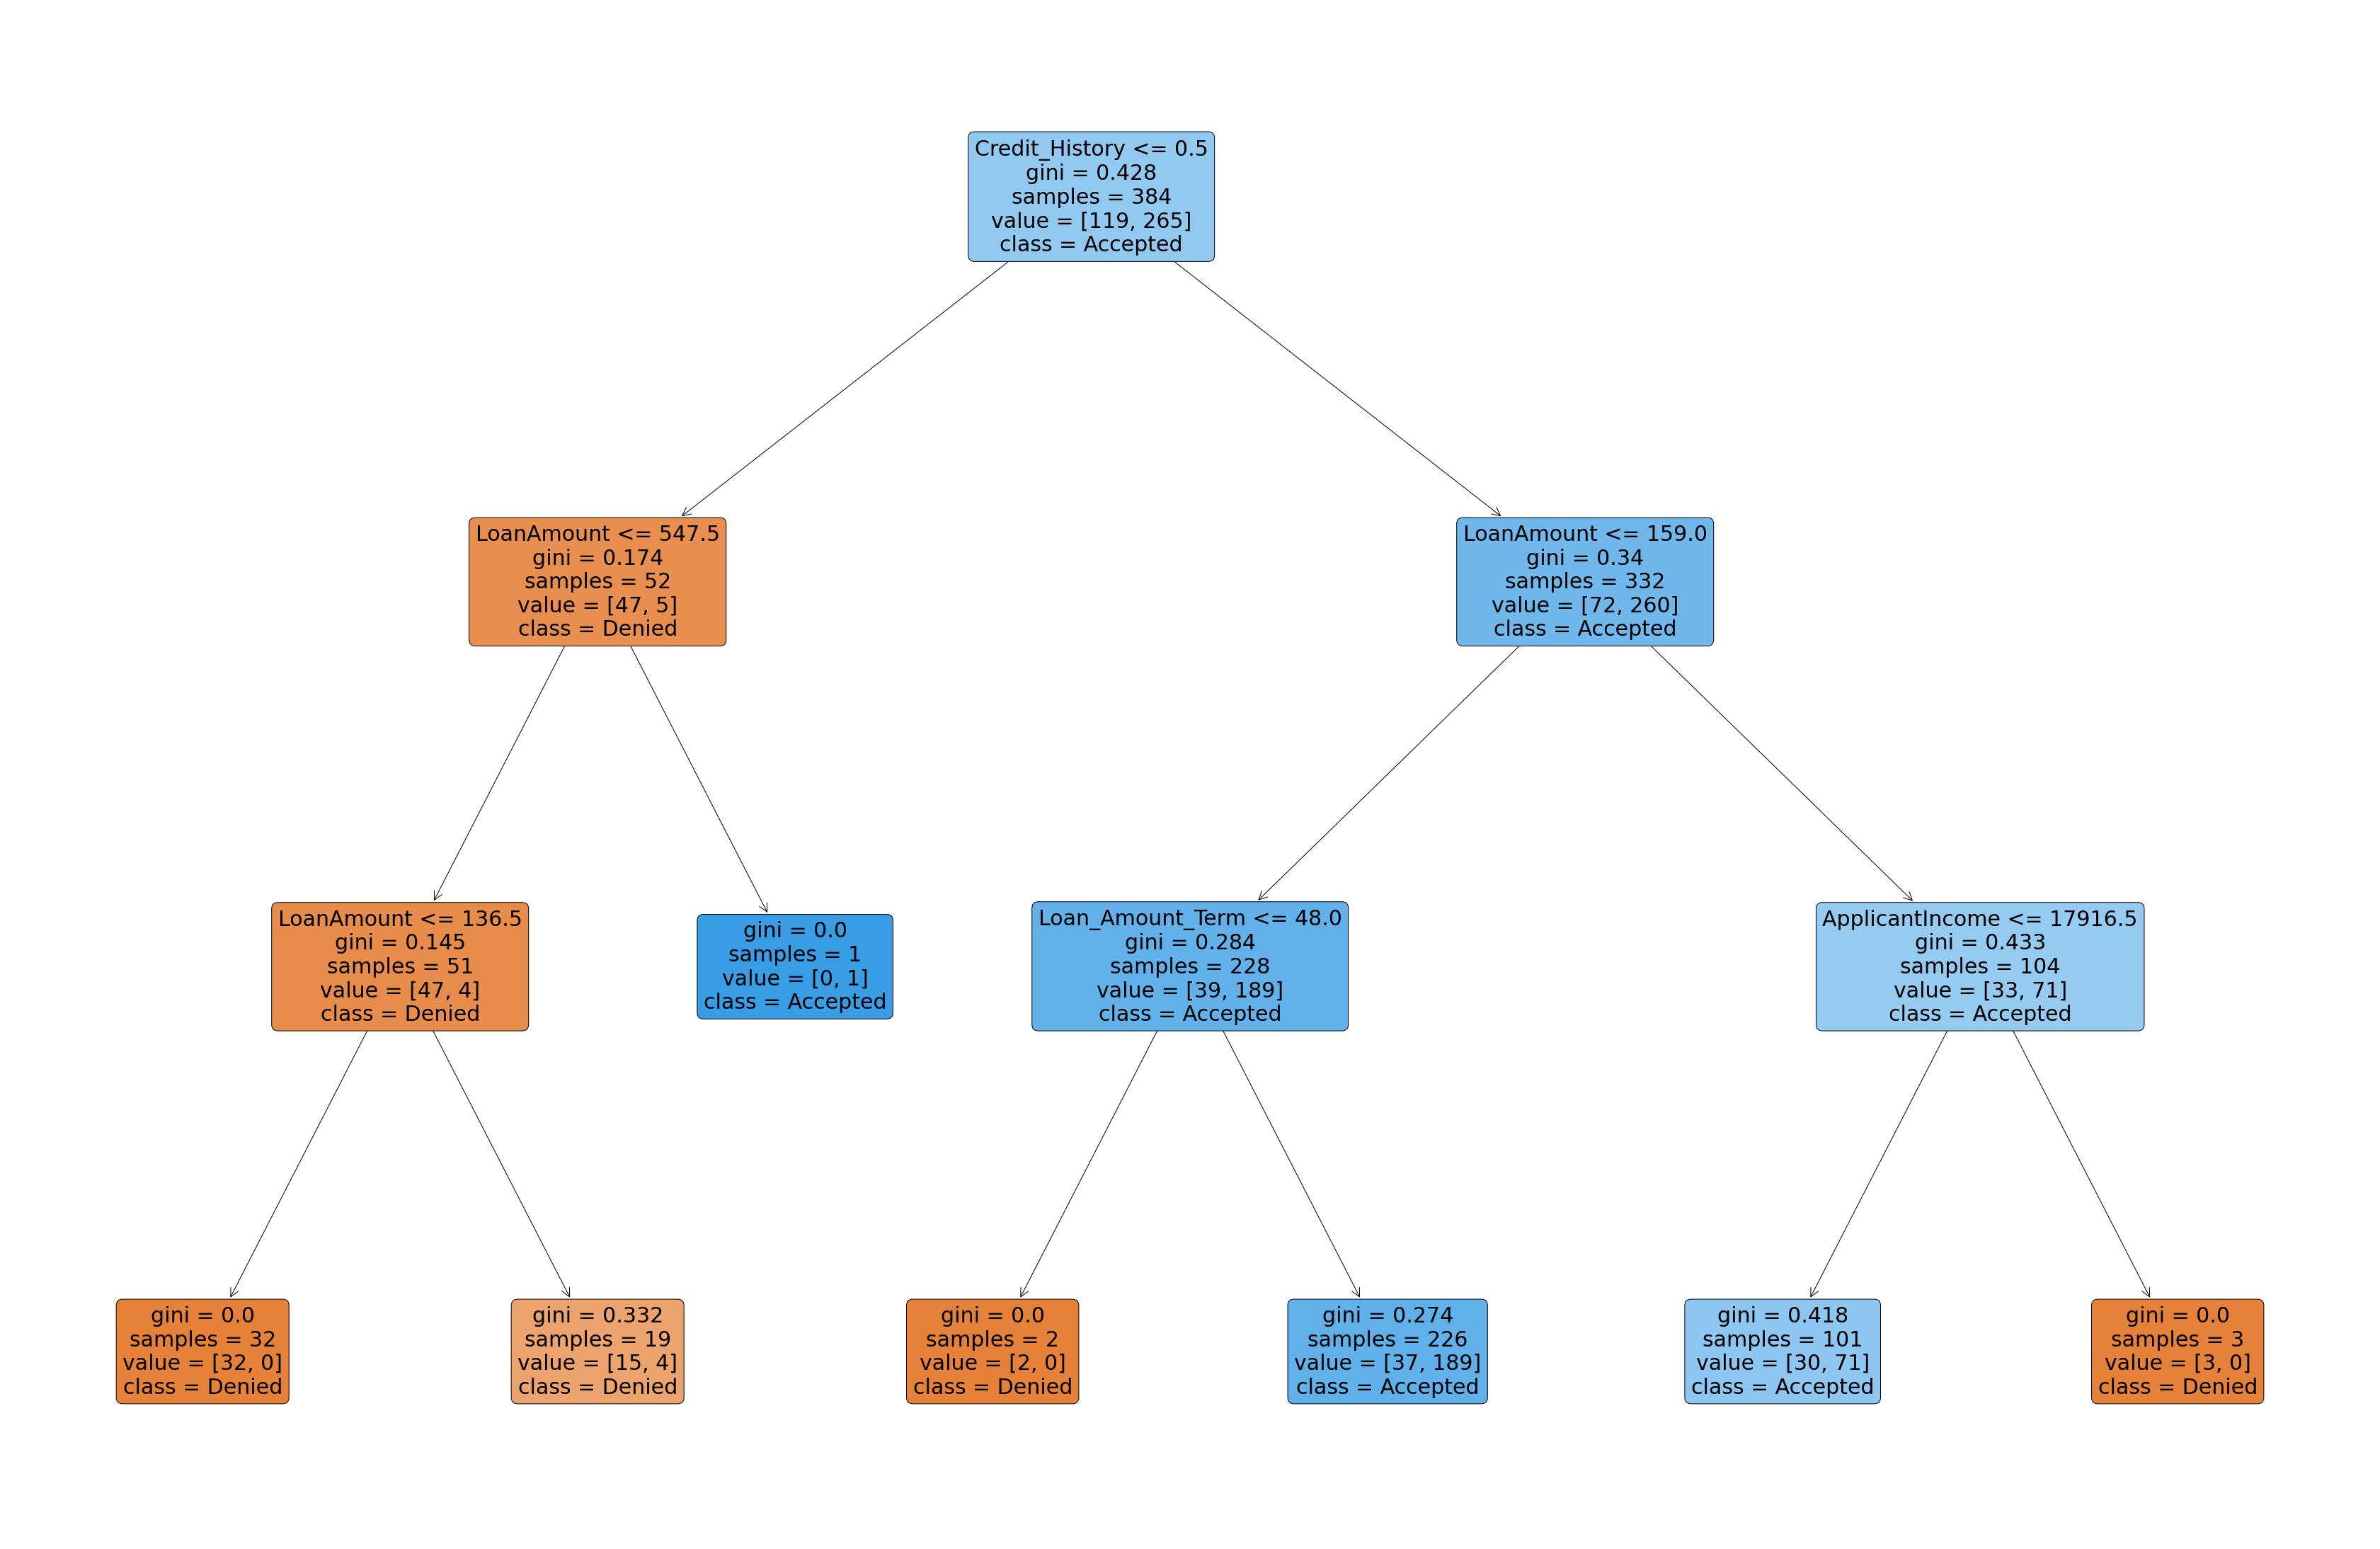

In [ ]:
# Creating the tree with the plot tree function
# Use the figsize of plt.figure to control the size of the rendering 
plt.figure(figsize=(60,40))
plot_tree(model,
         feature_names = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
          class_names = ["Denied","Accepted"], filled=True, rounded=True, fontsize=30)

## Suport Vector Machine (SVC)

In [ ]:
from sklearn import svm 
model_SVC = svm.SVC(kernel="linear") # defining the method. I tested poli and rff but linear had the best accuracy (poli = 0,6875 /rff = 0,6875 )
model_SVC

SVC(kernel='linear')

In [ ]:
model_SVC.fit(X_train,Y_train)

SVC(kernel='linear')

In [ ]:
# Testing
Y_pred = model_SVC.predict(X_test)
Y_pred

array([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1], dtype=int64)

In [ ]:
# Comparing the predicted y with the real y find the accuracy
accuracy_score(Y_pred,Y_real)

0.78125

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
 

In [ ]:
# For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones.
log_reg = LogisticRegression(solver = 'liblinear')

In [ ]:
#training the model 
log_reg.fit(X_train,Y_train)

LogisticRegression(solver='liblinear')

In [ ]:
#salvando o teste do modelo numa variável 
y_pred = log_reg.predict(X_test)

In [ ]:
y_pred #note the large amount of zeros. Means that the models is predicting more situations where the result is False. Note q por isso o modelo ficará mais biased para rejeitar do que aceitar  

array([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1], dtype=int64)

In [ ]:
 
# Accuracy = true negatives + true positives / true positives + false positives + true negatives + false negatives
acc = accuracy_score(Y_real,y_pred)  
acc

0.84375

## PART 3 - Valuation Analysis: using kfold, a model validation technique

### Performance Measurement (accuracy score) 

In [ ]:
# I have found the accuracy score for the Decision Tree model (line 130) and SVM model (line 136). 
# Here are the results: 

# -> Decision Tree model  - accuracy score:  0.84375
# -> SVM model - accuracy score:  0.78125
# -> Logistic Regression model - accuracy score: 0.84375

### Kfold -> Decision Tree

In [ ]:
# Now using kfold, a model validation technique where it's not using your pre-trained model
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kf = KFold(n_splits=5,shuffle=True)  
cv_r = cross_val_score(model, X, Y, cv=kf)
np.mean(cv_r)

0.8

### Kfold -> Support Vector Machine

In [ ]:
kf_svm = KFold(n_splits=5,shuffle=True)  
# first parameter = Number of folds. Must be at least 2.
# second parameter = Whether to shuffle the data before splitting into batches.

In [ ]:
# Evaluating a score by cross-validation  
cv_svm = cross_val_score(model_SVC, X, Y, cv=kf_svm)  
# first parameter = The object to use to fit the data.
# second parameter = X
# second parameter = Y
# third parameter = cross validation
# NOTE: it took the empty model, trained it, tested it and compared the test result (predicted y) with the real y.
# after making this comparison it returns the accuracy of each fold (5)
cv_svm

array([0.73958333, 0.8125    , 0.78125   , 0.79166667, 0.84375   ])

In [ ]:
# Mean accuracy 
np.mean(cv_svm)

0.79375

### Kfold -> Logistic Regression

In [ ]:
kf_lg = KFold(n_splits=5,shuffle=True)

In [ ]:
cv_lg = cross_val_score(model_SVC, X, Y, cv=kf_lg)  

In [ ]:
# Mean accuracy 
np.mean(cv_lg)

0.7916666666666666